In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product
import math
import scienceplots

plt.style.use(['science','nature'])
plt.rcParams.update({'figure.dpi': '300'})

from scipy import signal
from scipy import stats
from scipy.interpolate import make_smoothing_spline

# Be careful of 2pi errors.

def rpm(rad_per_second):
    return (rad_per_second / (2 * math.pi)) * 60

def rad_per_sec(rpm_input):
    return (rpm_input * (2 * math.pi)) / 60

e0 = 8.854e-12

df_27_kV = pd.read_csv('20250919_processed_video_csv/27_50_kV_no_box_2025_09_19_Trial4_full.csv', delimiter="\t", names=["time(s)", "frame", "x", "y", "r", "theta", "omega(deg/sec)", "pixelx", "pixely", "i"])
df_27_kV = df_27_kV.iloc[2:]
df_27_kV = df_27_kV.reset_index(drop=True)
df_27_kV = df_27_kV.apply(pd.to_numeric, errors='coerce')


df_28_kV = pd.read_csv('20250919_processed_video_csv/28_50_kV_no_box_2025_09_19_Trial4_full.csv', delimiter="\t", names=["time(s)", "frame", "omega(deg/sec)", "x", "y", "r", "theta", "pixelx", "pixely", "i"])
df_28_kV = df_28_kV.iloc[2:]
df_28_kV = df_28_kV.reset_index(drop=True)
df_28_kV = df_28_kV.apply(pd.to_numeric, errors='coerce')

df_29_kV = pd.read_csv('20250919_processed_video_csv/29_00_kV_no_box_2025_09_19_Trial27_check_voltage.csv', delimiter="\t", names=["time(s)", "frame", "x", "y", "r", "theta", "omega(deg/sec)", "pixelx", "pixely", "i"])

#df_29_kV = pd.read_csv('20250919_processed_video_csv\\29_70_kV_no_box_2025_09_19_Trial2_full.csv', delimiter="\t", names=["time(s)", "frame", "x", "y", "r", "theta", "omega(deg/sec)", "pixelx", "pixely", "i"])
#df_29_kV = pd.read_csv('20250919_processed_video_csv\\29_50_kV_no_box_2025_09_19_Trial5_0_to_50348_corrected_columns.csv', delimiter="\t", names=["time(s)", "frame", "x", "y", "r", "theta", "omega(deg/sec)", "pixelx", "pixely", "i"])



df_29_kV = df_29_kV.iloc[2:]
df_29_kV = df_29_kV.reset_index(drop=True)
df_29_kV = df_29_kV.apply(pd.to_numeric, errors='coerce')





#print(df_27_kV)
#print("Column headers from list(df.columns.values):",
#      list(df_27_kV.columns.values))


def butterworth_filter(data, cutoff_freq, sampling_rate, order=4):
    nyquist = 0.5 * sampling_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(order, normal_cutoff, btype="low", analog=False)
    y_smoothed = signal.filtfilt(b, a, data)
    return y_smoothed




cutoff_freq = 99
sampling_rate = 200
order = 3




m_rotor = 0.00140 + 0.0002 # kg 11.5 grams plust he tape.
r_rotor = 0.029 # m

m_rotor_supports = 0.00685
r_rotor_supports = 0.029

m_shaft = 0.002
r_shaft = 0.003
I_rotor =  m_rotor * r_rotor**2 + 0.5 * m_rotor_supports * r_rotor_supports**2 + 0.5 *2 * m_shaft *r_shaft**2
print(I_rotor)

dataframes = [df_27_kV, df_28_kV, df_29_kV]



def coordinate_transform_and_filter(df, window=200):
    df["x_c"] = np.NAN
    df["y_c"] = np.NAN
    for i in range(len(df) - window):
        df["x_c"][i] = (max(df["x"][i:i+window]) + min(df["x"][i:i+window])) / 2
        df['y_c'][i] = (max(df["y"][i:i+window]) + min(df["y"][i:i+window])) / 2
    df['x_c'].ffill(inplace=True)
    df['y_c'].ffill(inplace=True)
    df["theta"] = np.arctan2( (df["y"] - df['y_c']), (df["x"] - df['x_c']))
    df["omega(rad/s)"] =  -df["theta"].diff(periods=-1) / df["dt(s)"]
    return df



for df in dataframes:
    df["time(s)"] = df["time(s)"] - df["time(s)"][0]
    df["dt(s)"] = -df["time(s)"].diff(periods=-1)
    df["omega(rad/s)"] = (2*math.pi / 360) * df["omega(deg/sec)"] 
    df["omega(rad/s)"] = df["omega(rad/s)"].ewm(span=10).mean()
    #df["omega(rad/s)"] = df["omega(rad/s)"].ewm(span=30).mean()   

    #df = df.ffill()
    df.fillna(0, inplace=True)
    spl = make_smoothing_spline(df["time(s)"], df["omega(rad/s)"], lam=0.1)
    df["omega(rad/s)"] = spl(df["time(s)"])


    #df = coordinate_transform_and_filter(df)
    df["alpha(rad/s/s)"] = -df["omega(rad/s)"].diff(periods=-1) / df["dt(s)"]
    df["alpha(rad/s/s)"] = df["alpha(rad/s/s)"].ewm(span=5).mean()
    df["alpha(rad/s/s)"] = df["alpha(rad/s/s)"].rolling(5).mean()
    #sos = signal.butter(10, 20, 'lp', fs=1000, output='sos')
    #df["alpha(rad/s/s)"] = signal.sosfilt(sos, df["alpha(rad/s/s)"])
    #df["alpha(rot/s/s)"] = df["alpha(rot/s/s)"].rolling(window=2, closed="left").mean()
    #print(df["omega(rad/s)"])
    #df = df.fillna(0)
    #df["omega(rad/s)"] = butterworth_filter(df["omega(rad/s)"], cutoff_freq, sampling_rate, order)
    #print(df["alpha(rad/s/s)"])
    #df = df.fillna(0)
    print("torque")
    df["T(Nm)"] = I_rotor * df["alpha(rad/s/s)"]
    print("torque done")

    #print(df["T(Nm)"])
print(df_27_kV)




4.244025e-06
torque
torque done
torque
torque done
torque
torque done
      time(s)    frame         x         y         r         theta  \
0       0.000   8960.0  20.17834 -17.93631  26.99772     -41.63354   
1       0.004   8968.0  20.25976 -17.83010  26.98834     -41.35018   
2       0.008   8976.0  20.31234 -17.76441  26.98454     -41.17172   
3       0.012   8984.0  20.33583 -17.71248  26.96810     -41.05582   
4       0.016   8992.0  20.37557 -17.67825  26.97563     -40.94555   
...       ...      ...       ...       ...       ...           ...   
6220   24.880  58720.0  22.38685  13.89308  26.34746  123151.80000   
6221   24.884  58728.0  22.40117  13.86985  26.34739  123151.80000   
6222   24.888  58736.0  22.41716  13.83827  26.34438  123151.70000   
6223   24.892  58744.0  22.41002  13.82328  26.33044  123151.70000   
6224   24.896  58752.0  22.43678  13.74724  26.31342  123151.50000   

      omega(deg/sec)    pixelx    pixely    i  dt(s)  omega(rad/s)  \
0            0.0000

-27.7186
28.90613
0          137.3174
1          137.9881
2          138.5956
3          139.2109
4          140.2745
           ...     
6647    139081.2000
6648    139081.2000
6649    139081.2000
6650    139081.1000
6651    139081.1000
Name: theta, Length: 6652, dtype: float64


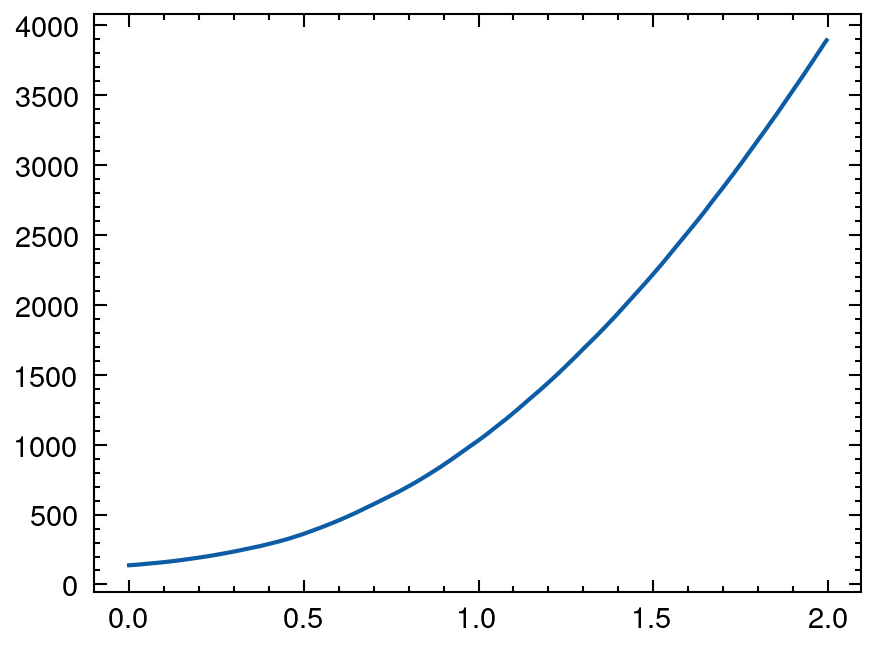

In [2]:


#print(min(df_28_kV["x_c"]))
print(min(df_28_kV["x"]))
print(max(df_28_kV["x"]))
#print(max(df_28_kV["x_c"]))
print(df_28_kV["theta"])
#plt.plot(df_28_kV["time(s)"], df_28_kV["x"])
#plt.plot(df_28_kV["time(s)"], df_28_kV["y"])
#plt.plot(df_28_kV["time(s)"], np.sqrt((df_28_kV["x"] - df_28_kV["x_c"])**2 + (df_28_kV["y"] - df_28_kV["y_c"])**2) , label="28.5 kV")
#plt.plot(df_28_kV["time(s)"], df_28_kV["r"], label="28.5 kV")
plt.plot(df_28_kV["time(s)"][0:500], df_28_kV["theta"][0:500], label="28.5 kV")

<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:3: SyntaxWarning: invalid escape sequence '\,'
<>:4: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/3769633944.py:3: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(df_29_kV["time(s)"][500:], rpm(df_29_kV["omega(rad/s)"])[500:], label="-29.0\,kV")
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/3769633944.py:4: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(df_28_kV["time(s)"][index:], rpm(df_28_kV["omega(rad/s)"])[index:], label="-28.5\,kV")
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/3769633944.py:5: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(df_27_kV["time(s)"][index:], rpm(df_27_kV["omega(rad/s)"])[index:], label="-27.5\,kV")


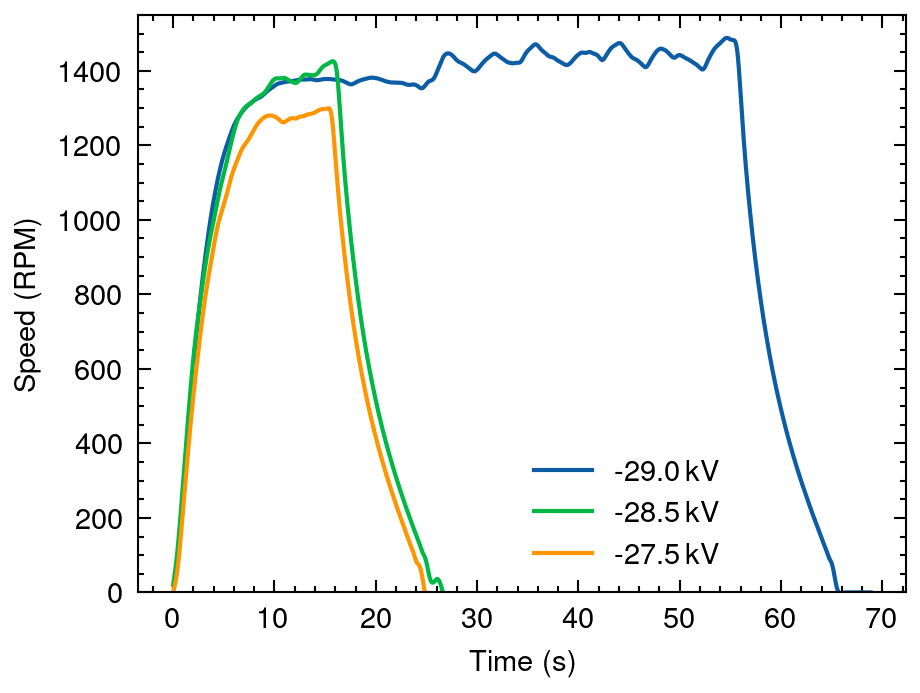

In [3]:
index = 0

plt.plot(df_29_kV["time(s)"][500:], rpm(df_29_kV["omega(rad/s)"])[500:], label="-29.0\,kV")
plt.plot(df_28_kV["time(s)"][index:], rpm(df_28_kV["omega(rad/s)"])[index:], label="-28.5\,kV")
plt.plot(df_27_kV["time(s)"][index:], rpm(df_27_kV["omega(rad/s)"])[index:], label="-27.5\,kV")

plt.xlabel("Time (s)")

plt.ylabel("Speed (RPM)")
plt.ylim(0,1550)

plt.legend(loc = (0.5, 0.02))

plt.savefig("figures_20250919/speed_time_series.pdf", format="pdf")  
plt.savefig("figures_20250919/speed_time_series.png")  


<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:12: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:12: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/4049591143.py:6: SyntaxWarning: invalid escape sequence '\,'
  axs[0].plot(df_29_kV["time(s)"][index:index_end], rpm(df_29_kV["omega(rad/s)"])[index:index_end], label="-29.0\,kV")
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/4049591143.py:7: SyntaxWarning: invalid escape sequence '\,'
  axs[0].plot(df_28_kV[

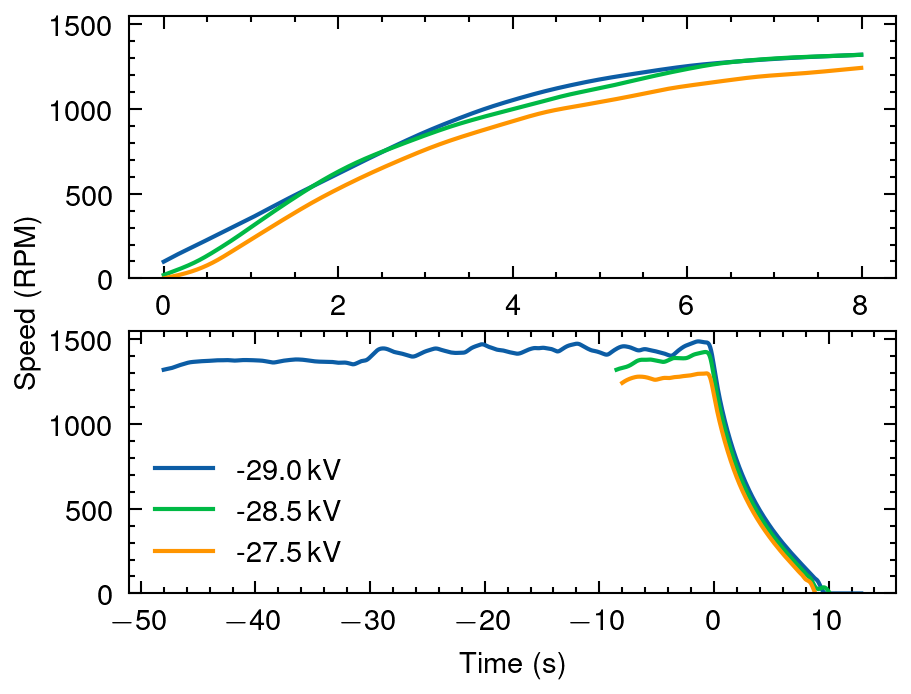

In [4]:
fig, axs = plt.subplots(2)

index = 0
index_end = 2000

axs[0].plot(df_29_kV["time(s)"][index:index_end], rpm(df_29_kV["omega(rad/s)"])[index:index_end], label="-29.0\,kV")
axs[0].plot(df_28_kV["time(s)"][index:index_end], rpm(df_28_kV["omega(rad/s)"])[index:index_end], label="-28.5\,kV")
axs[0].plot(df_27_kV["time(s)"][index:index_end], rpm(df_27_kV["omega(rad/s)"])[index:index_end], label="-27.5\,kV")


axs[1].plot(df_29_kV["time(s)"][index_end:] - 56, rpm(df_29_kV["omega(rad/s)"])[index_end:], label="-29.0\,kV")
axs[1].plot(df_28_kV["time(s)"][index_end:]+39.5 -56, rpm(df_28_kV["omega(rad/s)"])[index_end:], label="-28.5\,kV")
axs[1].plot(df_27_kV["time(s)"][index_end:]+40-56, rpm(df_27_kV["omega(rad/s)"])[index_end:], label="-27.5\,kV")

plt.xlabel("Time (s)")

fig.supylabel("Speed (RPM)", fontsize=7, x=0.01)

axs[0].set_ylim(0, 1550)
axs[1].set_ylim(0, 1550)

#plt.axhline(1570)

plt.legend(loc='lower left',)

plt.savefig("figures_20260817/speed_time_series.pdf", format="pdf")  
plt.savefig("figures_20260817/speed_time_series.png")  


Text(0, 0.5, 'speed (rpm)')

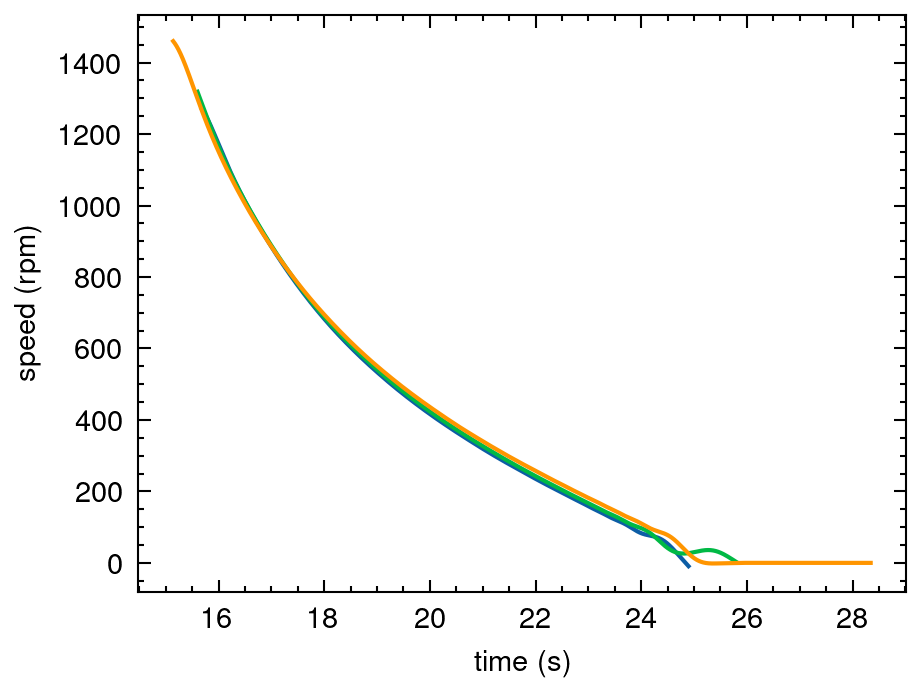

In [5]:


index = 3920

plt.plot(df_27_kV["time(s)"][index:], rpm(df_27_kV["omega(rad/s)"])[index:])
plt.xlabel("time (s)")

plt.ylabel("speed (rpm)")


index = 4100

plt.plot(df_28_kV["time(s)"][index:] - 0.8, rpm(df_28_kV["omega(rad/s)"])[index:])
plt.xlabel("time (s)")

plt.ylabel("speed (rpm)")



index = 13910

plt.plot(df_29_kV["time(s)"][index:] - 40.5, rpm(df_29_kV["omega(rad/s)"])[index:])
plt.xlabel("time (s)")

plt.ylabel("speed (rpm)")

<>:63: SyntaxWarning: invalid escape sequence '\O'
<>:63: SyntaxWarning: invalid escape sequence '\O'
<>:63: SyntaxWarning: invalid escape sequence '\O'
<>:63: SyntaxWarning: invalid escape sequence '\O'
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/1422894792.py:63: SyntaxWarning: invalid escape sequence '\O'
  plt.plot (omega_list, -1000*fit(omega_list), color="grey", linestyle='dashed', label= "Fit: " + format(-coeffs[0], ".2e") + "$\Omega^2$ + " + format(-coeffs[1], ".2e") + "$\Omega$ + \n" + "      "+ format(-coeffs[2], ".2e") +  ", $R^2$: "+ str(round(r_squared, 3)))
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/1422894792.py:63: SyntaxWarning: invalid escape sequence '\O'
  plt.plot (omega_list, -1000*fit(omega_list), color="grey", linestyle='dashed', label= "Fit: " + format(-coeffs[0], ".2e") + "$\Omega^2$ + " + format(-coeffs[1], ".2e") + "$\Omega$ + \n" + "      "+ format(-coeffs[2], ".2e") +  ", $R^2$: "+ str(round(r_squared, 3)))


(np.float64(-8.566609172431593e-11), np.float64(-8.447523992991354e-09), np.float64(-2.8297041899822015e-05)) 0.997097216771507
-8.566609172431593e-11


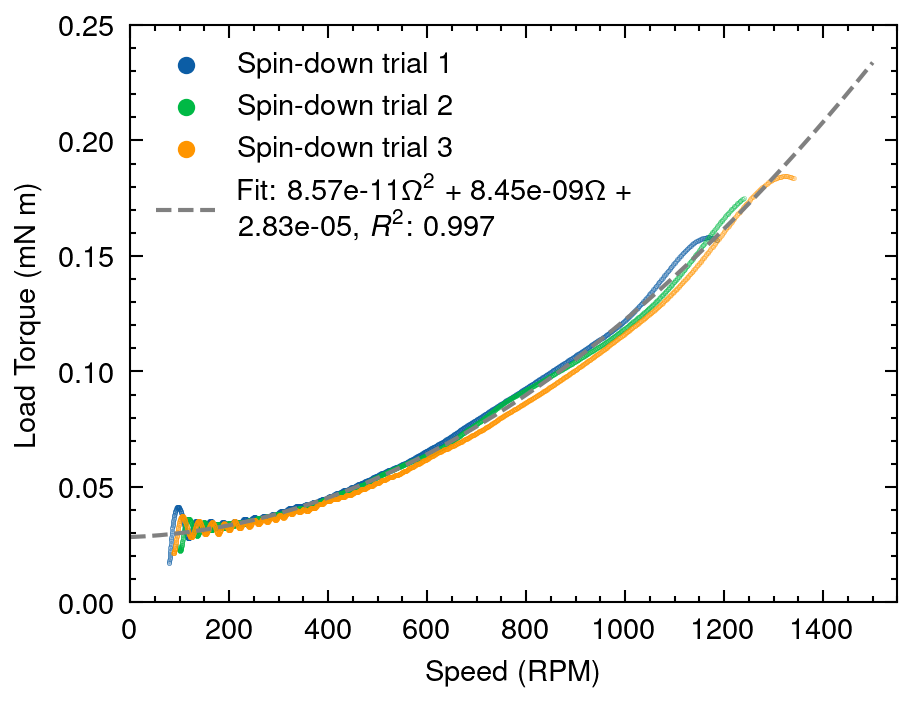

In [6]:


def quad_fit(x, y):
    """
    This method was written by Claude.
    Fit a quadratic function to data and return coefficients and R² value.
    
    Parameters:
    -----------
    x : array-like
        Independent variable data
    y : array-like
        Dependent variable data
    
    Returns:
    --------
    coeffs : tuple
        Quadratic coefficients (a, b, c) for y = ax² + bx + c
    r_squared : float
        R² value indicating goodness of fit
    """
    # Convert to numpy arrays
    x = np.array(x)
    y = np.array(y)
    
    # Fit quadratic polynomial (degree 2)
    coeffs = np.polyfit(x, y, 2)
    
    # Calculate predicted values
    y_pred = np.polyval(coeffs, x)
    
    # Calculate R² value
    ss_res = np.sum((y - y_pred)**2)  # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)  # Total sum of squares
    r_squared = 1 - (ss_res / ss_tot)
    
    return tuple(coeffs), r_squared



plt.scatter(rpm(df_27_kV["omega(rad/s)"][3990:-200]), -df_27_kV["T(Nm)"][3990:-200] * 1000, alpha=0.5, s = 0.025, label="Spin-down trial 1")
plt.scatter(rpm(df_28_kV["omega(rad/s)"][4150:6200]), -df_28_kV["T(Nm)"][4150:6200] * 1000, alpha=0.5, s = 0.025, label="Spin-down trial 2")
plt.scatter(rpm(df_29_kV["omega(rad/s)"][14000:-1000]), -df_29_kV["T(Nm)"][14000:-1000] * 1000, alpha=0.5, s = 0.025, label="Spin-down trial 3")


#def fit(omega):
#    return -0.00003 - 0.0000000014 * ( omega) -  0.00000000009 * ( omega)**2



omega_list = np.linspace(0, 1500)

coeffs, r_squared = quad_fit(rpm(df_28_kV["omega(rad/s)"][4150:6200]), df_28_kV["T(Nm)"][4150:6200])

def fit(omega):
    return coeffs[2] + coeffs[1] * ( omega) +  coeffs[0] * ( omega)**2


print(coeffs, r_squared)

print(coeffs[0])

plt.xlim(0,1550)
plt.ylim(0, 0.00025*1000)
plt.plot (omega_list, -1000*fit(omega_list), color="grey", linestyle='dashed', label= "Fit: " + format(-coeffs[0], ".2e") + "$\Omega^2$ + " + format(-coeffs[1], ".2e") + "$\Omega$ + \n" + "      "+ format(-coeffs[2], ".2e") +  ", $R^2$: "+ str(round(r_squared, 3)))
plt.ylabel("Load Torque (mN m)")
plt.xlabel("Speed (RPM)")


plt.rcParams["legend.markerscale"] = 20

leg = plt.legend()

for lh in leg.legend_handles: 
    lh.set_alpha(1)
plt.savefig("figures_20250919/Spindown.pdf", format="pdf")  
plt.savefig("figures_20250919/Spindown.png") 



<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/2628033460.py:6: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(rpm(df_29_kV["omega(rad/s)"][:11500:frequency]), (df_29_kV["T(Nm)"][:11500:frequency] - fit(rpm(df_29_kV["omega(rad/s)"])[:11500:frequency])) *  1000,  label="-29.0\,kV")
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/2628033460.py:7: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(rpm(df_28_kV["omega(rad/s)"][20:2700:frequency]), (df_28_kV["T(Nm)"][20:2700:frequency] - fit(rpm(df_28_kV["omega(rad/s)"])[20:2700:frequency])) *  1000,

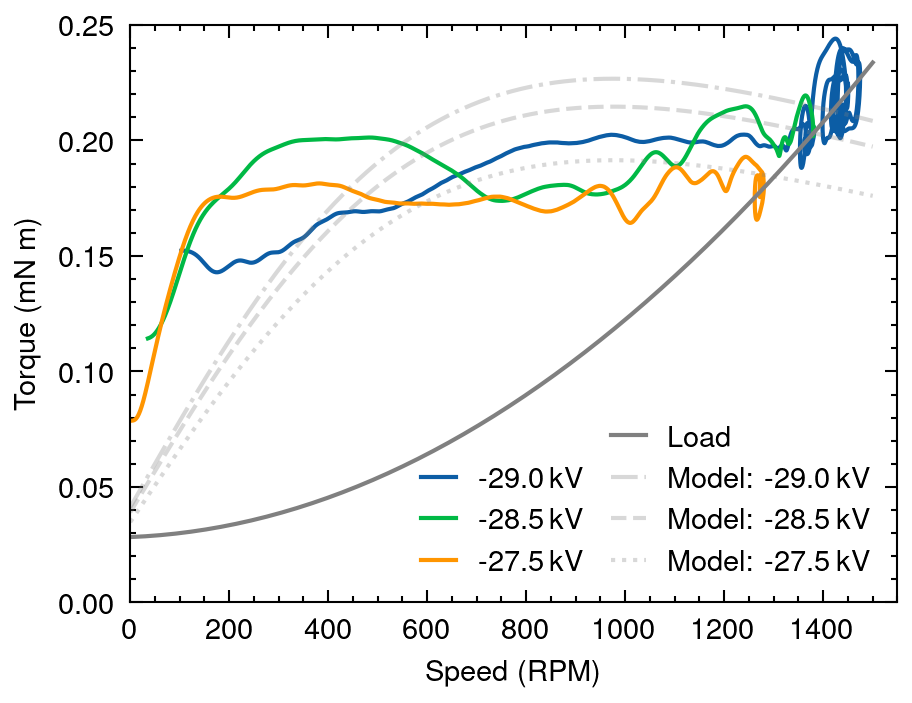

In [7]:
size=0.1
frequency=1

plt.plot(np.nan, np.nan, '-', color='none', label=' ') # fake plot to take space in the legend.

plt.plot(rpm(df_29_kV["omega(rad/s)"][:11500:frequency]), (df_29_kV["T(Nm)"][:11500:frequency] - fit(rpm(df_29_kV["omega(rad/s)"])[:11500:frequency])) *  1000,  label="-29.0\,kV")
plt.plot(rpm(df_28_kV["omega(rad/s)"][20:2700:frequency]), (df_28_kV["T(Nm)"][20:2700:frequency] - fit(rpm(df_28_kV["omega(rad/s)"])[20:2700:frequency])) *  1000,label="-28.5\,kV")
plt.plot(rpm(df_27_kV["omega(rad/s)"][:3100:frequency]), (df_27_kV["T(Nm)"][:3100:frequency] - fit(rpm(df_27_kV["omega(rad/s)"])[:3100:frequency])) *  1000,  label="-27.5\,kV")

plt.plot (omega_list, -fit(omega_list) *  1000 , label="Load", color="gray")


eps0=8.854e-12
V_initial = 10500
eps_g=eps0
eps_r=eps0
R=0.030
#L=0.052
L=0.054
G=0.0035
#alpha=0.15
alpha=0.10
sigma = 2e-9

V_array = [29000, 28500, 27500]

linestyles = ['dashdot', 'dashed', 'dotted']

for i in range(len(V_array)):
    V = V_array[i]
    E_eff=(V-V_initial)/(2*R+2*G)
    tau = (eps_g + eps_r) / sigma
    omega = np.linspace(0, rad_per_sec(1500), 1000) # fix radians per second. 
    T_model = 2 * np.pi * L * R**2 * eps_g * E_eff**2 * ((np.sin(alpha)+  (omega * tau)* np.cos(alpha)) / (1 + (omega*tau)**2)) + \
        4 * np.pi * L * R**2 * ((eps_g*eps_r) / (eps_r+eps_g)) * E_eff**2 * ((np.sin(alpha)+  (omega * tau)* np.cos(alpha)) / (1 + (omega*tau)**2))
    plt.plot (rpm(omega), T_model * 1000 , label="Model: -" + str((V / 1000)) + "\,kV", color="gray", alpha = 0.3, linestyle = linestyles[i])




plt.xlim(0,1550)
plt.ylim(0,0.00025 * 1000)
plt.ylabel("Torque (mN m)")
plt.xlabel("Speed (RPM)")
plt.rcParams["legend.markerscale"] = 10
leg = plt.legend(ncol=2, loc='lower right', handlelength=1.2, columnspacing=0.9)
#leg = plt.legend(ncol=2, bbox_to_anchor=(0, 1), loc="lower left", fancybox=True, shadow=True)
#leg = plt.legend(ncol=2, bbox_to_anchor=(0.5, -0.15), loc="upper center", fancybox=True, shadow=True)
   
plt.savefig("figures_20250919/speed_torque_curve.pdf", format="pdf")  
plt.savefig("figures_20250919/speed_torque_curve.png")  

# Now plot the voltage dataset.

In [8]:
df_voltage = pd.read_csv('20250919_processed_video_csv/voltage_speed_data.csv', delimiter="\t", names=["V", "t0", "t1", "speed(rpm)"])

df_voltage = df_voltage.iloc[1:]
df_voltage = df_voltage.reset_index(drop=True)
df_voltage = df_voltage.apply(pd.to_numeric, errors='coerce')

res = stats.linregress(df_voltage["V"], df_voltage["speed(rpm)"])

print(f"R-squared: {res.rvalue**2:.6f}")

R-squared: 0.991260


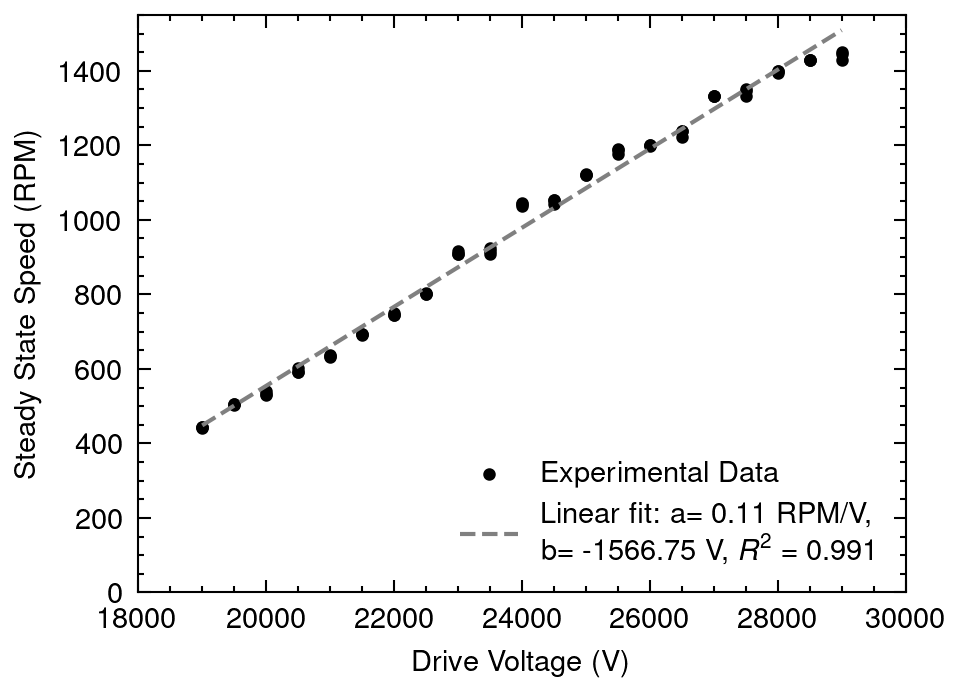

In [9]:
plt.scatter(df_voltage["V"], df_voltage["speed(rpm)"], label = "Experimental Data", s=4, c="black")

#plt.scatter(df_voltage["V"], fit(df_voltage["speed(rpm)"]))

plt.plot(df_voltage["V"], res.intercept + res.slope*df_voltage["V"], 'grey', linestyle = 'dashed', label='Linear fit: a= '+ str(round(res.slope, 2)) +' RPM/V, \n b= ' + str(round(res.intercept, 2)) + ' V, $R^2$ = ' + str(round(res.rvalue**2, 3)))

#plt.plot(df_voltage["V"], poly1d_fn(df_voltage["V"]), color = "grey", linestyle='dashed')

plt.ylim(0,1550)
plt.xlim(18000,30000)
plt.xlabel("Drive Voltage (V)")
plt.ylabel("Steady State Speed (RPM)")
plt.rcParams["legend.markerscale"] = 1
plt.legend(ncol=1, loc='lower right')
#plt.savefig("Speed_vs_voltage.pdf", format="pdf")  

<>:42: SyntaxWarning: invalid escape sequence '\,'
<>:42: SyntaxWarning: invalid escape sequence '\,'
<>:42: SyntaxWarning: invalid escape sequence '\,'
<>:42: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/3166420562.py:42: SyntaxWarning: invalid escape sequence '\,'
  bax.plot(df_voltage["V"]/1000, res.intercept + res.slope*df_voltage["V"], 'grey', linestyle = 'dashed', label='Linear fit: a = '+ str(round(res.slope, 2)) +'\,RPM/V, \n b = ' + str(round(res.intercept, 2)) + '\,V, $R^2$ = ' + str(round(res.rvalue**2, 3)))
/var/folders/g8/dtw57z4s7yv9284q869ssqbc0000gn/T/ipykernel_14814/3166420562.py:42: SyntaxWarning: invalid escape sequence '\,'
  bax.plot(df_voltage["V"]/1000, res.intercept + res.slope*df_voltage["V"], 'grey', linestyle = 'dashed', label='Linear fit: a = '+ str(round(res.slope, 2)) +'\,RPM/V, \n b = ' + str(round(res.intercept, 2)) + '\,V, $R^2$ = ' + str(round(res.rvalue**2, 3)))


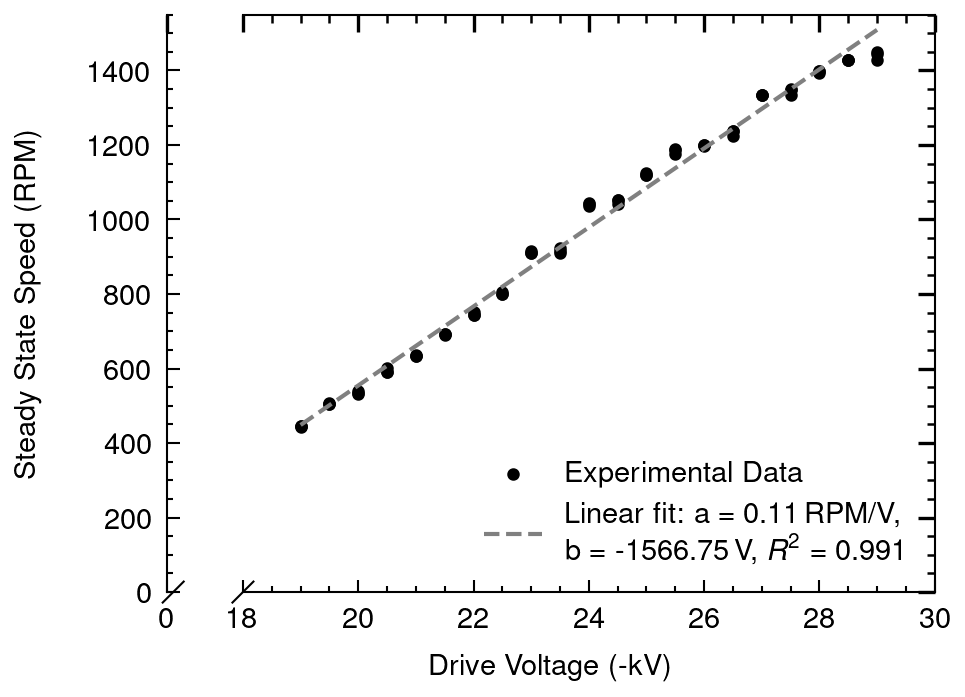

In [10]:
from brokenaxes import brokenaxes



def force_ticks(event):
    """Force tick2line to be visible on every draw, but only on outer edges"""
    for i, ax in enumerate(bax.axs):
        # For x-axis: all axes get top ticks
        for tick in ax.xaxis.get_major_ticks():
            tick.tick2line.set_visible(True)
            tick.tick2line.set_markersize(4)
            tick.tick2line.set_markeredgewidth(0.8)
        for tick in ax.xaxis.get_minor_ticks():
            tick.tick2line.set_visible(True)
            tick.tick2line.set_markersize(2)
            tick.tick2line.set_markeredgewidth(0.6)
        
        # For y-axis: only the rightmost axis gets right ticks
        if i == len(bax.axs) - 1:  # Only the last (rightmost) axis
            for tick in ax.yaxis.get_major_ticks():
                tick.tick2line.set_visible(True)
                tick.tick2line.set_markersize(4)
                tick.tick2line.set_markeredgewidth(0.8)
            for tick in ax.yaxis.get_minor_ticks():
                tick.tick2line.set_visible(True)
                tick.tick2line.set_markersize(2)
                tick.tick2line.set_markeredgewidth(0.6)
        else:  # All other axes: explicitly hide right ticks
            for tick in ax.yaxis.get_major_ticks():
                tick.tick2line.set_visible(False)
            for tick in ax.yaxis.get_minor_ticks():
                tick.tick2line.set_visible(False)


fig = plt.figure()
bax = brokenaxes(
    xlims=((0, .1), (18000/1000, 30000/1000)),
    hspace=0.005
)

bax.scatter(df_voltage["V"]/1000, df_voltage["speed(rpm)"], label = "Experimental Data", s=4, c="black")
bax.plot(df_voltage["V"]/1000, res.intercept + res.slope*df_voltage["V"], 'grey', linestyle = 'dashed', label='Linear fit: a = '+ str(round(res.slope, 2)) +'\,RPM/V, \n b = ' + str(round(res.intercept, 2)) + '\,V, $R^2$ = ' + str(round(res.rvalue**2, 3)))
bax.set_ylim(0,1550)
bax.set_xlabel("Drive Voltage (-kV)")
bax.set_ylabel("Steady State Speed (RPM)")
bax.legend(ncol=1, loc='lower right')

bax.axs[1].spines['right'].set_visible(True)
bax.axs[1].spines['top'].set_visible(True)

fig.canvas.mpl_connect('draw_event', force_ticks)
fig.canvas.draw()
fig.savefig("figures_20250919/Speed_vs_voltage.pdf", format="pdf")  
fig.savefig("figures_20250919/Speed_vs_voltage.png")  




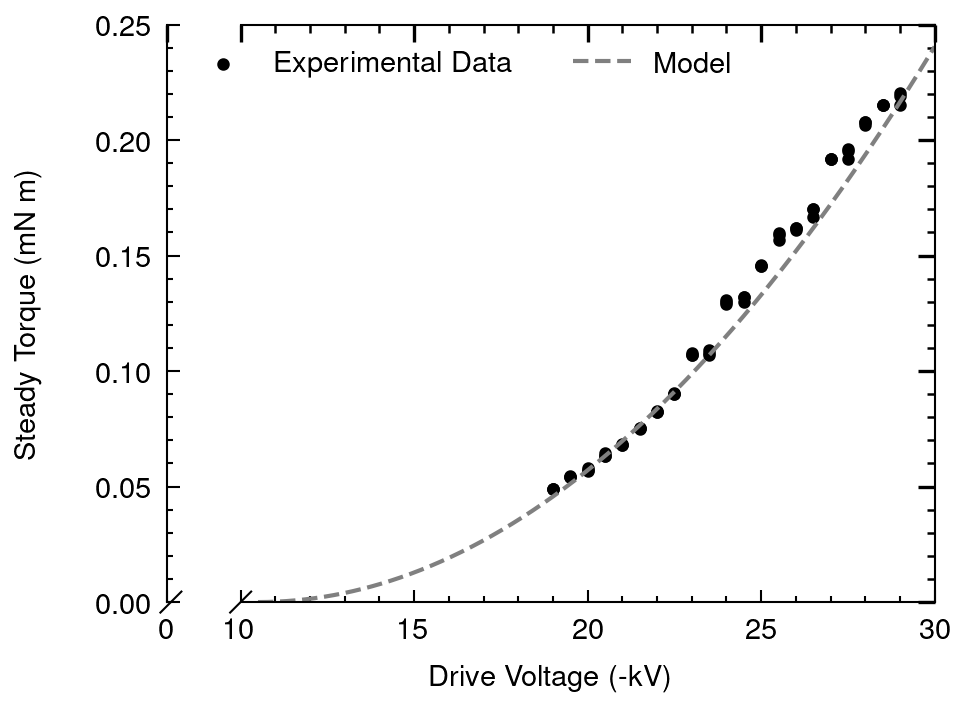

In [11]:
V = np.linspace(V_initial, 30000, 1000)


E_eff=(V-V_initial)/(2*R+2*G)

T_max = 2 * np.pi * L * R**2 * eps_g * E_eff**2 * (1+np.sin(alpha)) 

T_max = np.pi * L * R**2 * eps_g * E_eff**2 * (1+np.sin(alpha)) + 2* np.pi * L * R**2 * ((eps_g*eps_r) / (eps_r+eps_g)) * E_eff**2 


fig = plt.figure()
bax = brokenaxes(
    xlims=((0, .1), (10000/1000, 30000/1000)),
    hspace=0.005
)

bax.scatter(df_voltage["V"]/1000, -fit(df_voltage["speed(rpm)"])*1000, label = "Experimental Data", s=4, c="black")
bax.plot(V/1000, T_max*1000, 'grey', linestyle = 'dashed', label="Model") 
bax.set_ylim(0,0.00025*1000)
bax.set_xlabel("Drive Voltage (-kV)")
bax.set_ylabel("Steady Torque (mN m)")
bax.legend(ncol=2, loc='upper left')

bax.axs[1].spines['right'].set_visible(True)
bax.axs[1].spines['top'].set_visible(True)

fig.canvas.mpl_connect('draw_event', force_ticks)
fig.canvas.draw()
plt.savefig("figures_20250919/torque_vs_voltage.pdf", format="pdf")  
plt.savefig("figures_20250919/torque_vs_voltage.png")  


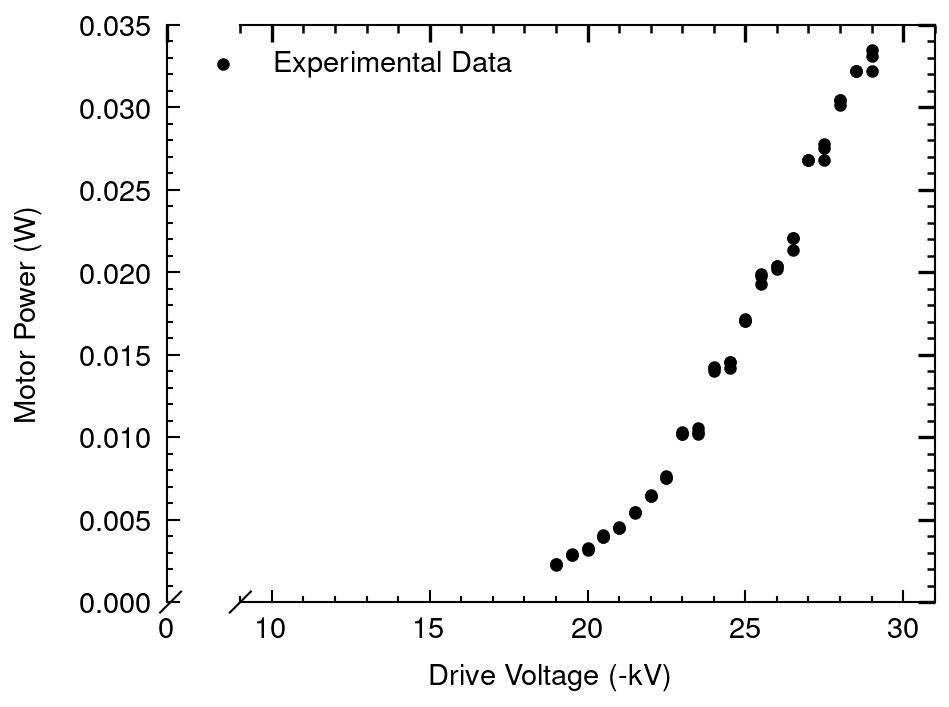

In [12]:

fig = plt.figure()
bax = brokenaxes(
    xlims=((0, .1), (9000/1000, 31000/1000)),
    hspace=0.005
)


bax.scatter(df_voltage["V"]/1000, -fit(df_voltage["speed(rpm)"]) * rad_per_sec(df_voltage["speed(rpm)"]), label = "Experimental Data", s=4, c="black")

bax.set_ylim(0,)
bax.set_xlabel("Drive Voltage (-kV)")
bax.set_ylabel("Motor Power (W)")
bax.legend(ncol=2, loc='upper left')

bax.axs[1].spines['right'].set_visible(True)
bax.axs[1].spines['top'].set_visible(True)

fig.canvas.mpl_connect('draw_event', force_ticks)
fig.canvas.draw()
plt.savefig("figures_20250919/motor_power_vs_voltage.pdf", format="pdf")  
plt.savefig("figures_20250919/motor_power_vs_voltage.png")  